# 1.2 Análisis de Correlaciones - Commodities Agrícolas y Predictores

## Objetivo

Analizar las **relaciones lineales** entre commodities agrícolas (variables objetivo) y predictores para identificar:
- Cointegración entre commodities agrícolas (comportamiento conjunto)
- Predictores más relevantes para cada commodity agrícola
- Relaciones fuertes (|r| > 0.5) que justifiquen feature engineering
- Clusters de commodities con drivers económicos similares

## Alcance

Este notebook se enfoca en:
1. **Commodities agrícolas como objetivo:** 15 commodities que queremos predecir
2. **Predictores:** 68 variables (commodities no-agrícolas, macro, PSD, clima)
3. **Período:** 2000-01-01 en adelante (consistente con config.START_DATE)
4. **Métrica:** Correlación de Pearson (relaciones lineales)

**IMPORTANTE:** Correlación NO implica causalidad. Se usa como herramienta exploratoria para selección de features.

In [1]:
"""
Setup - Configuración de entorno y librerías

IMPORTANTE: Este notebook debe ejecutarse DESPUÉS de 1.1-initial-exploration.ipynb
"""

import sys
from pathlib import Path
from IPython.display import display
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Agregar directorio raíz del proyecto al PYTHONPATH
project_root = Path.cwd().parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Librerías estándar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage

# Módulos del proyecto
from src.config import PROCESSED_DIR, FIGURES_DIR, START_DATE, END_DATE
from src.visualization import configurar_estilo_grafico, formatear_ejes

# Configurar estilo visual institucional (sin grids, colores UBA)
COLORES = configurar_estilo_grafico(dpi=120, base_fontsize=10, variante="claro")
%matplotlib inline

# Configurar display de pandas para mejor legibilidad
pd.options.display.max_columns = 100
pd.options.display.max_rows = 50
pd.options.display.float_format = '{:,.3f}'.format

print("Entorno configurado correctamente")
print(f"Directorio de trabajo: {Path.cwd()}")
print(f"Directorio raíz del proyecto: {project_root}")

Entorno configurado correctamente
Directorio de trabajo: c:\Users\AdministradorIT\OneDrive\UBA\Taller de Programacion\TPFinal\notebooks\1.0-exploratory
Directorio raíz del proyecto: c:\Users\AdministradorIT\OneDrive\UBA\Taller de Programacion\TPFinal


## 1. Cargar Datos Consolidados y Clasificar Variables

**Dataset:** `commodities_base_consolidated.csv` generado por `src/data/process.py`

**Filtro temporal:** 2000-01-01 en adelante (definido en `config.START_DATE`)

In [2]:
# Validar existencia del archivo consolidado
consolidated_file = PROCESSED_DIR / 'commodities_base_consolidated.csv'

if not consolidated_file.exists():
    raise FileNotFoundError(
        f"\nERROR: No se encontró el archivo {consolidated_file}\n"
        f"\nEjecuta primero:\n"
        f"  python src/data/process.py\n"
    )

# Cargar datos consolidados
print(f"Cargando datos desde: {consolidated_file}")
df = pd.read_csv(consolidated_file, parse_dates=['date'])

print(f"\nDatos cargados correctamente (sin filtrar)")
print(f"Dimensiones originales: {df.shape[0]:,} observaciones x {df.shape[1]} variables")
print(f"Período original: {df['date'].min().date()} hasta {df['date'].max().date()}")

# FILTRAR por rango temporal definido en config (START_DATE desde año 2000)
print(f"\n{'='*70}")
print(f"APLICANDO FILTRO TEMPORAL: {START_DATE} en adelante")
print(f"{'='*70}")

df = df[df['date'] >= START_DATE].copy()
df = df.reset_index(drop=True)

print(f"\nDatos filtrados al milenio (2000+)")
print(f"Dimensiones finales: {df.shape[0]:,} observaciones x {df.shape[1]} variables")
print(f"Período final: {df['date'].min().date()} hasta {df['date'].max().date()}")
print(f"Tamaño en memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

display(df.head(10))

Cargando datos desde: C:\Users\AdministradorIT\OneDrive\UBA\Taller de Programacion\TPFinal\data\processed\commodities_base_consolidated.csv

Datos cargados correctamente (sin filtrar)
Dimensiones originales: 6,981 observaciones x 99 variables
Período original: 1999-01-04 hasta 2025-11-10

APLICANDO FILTRO TEMPORAL: 2000-01-01 en adelante

Datos filtrados al milenio (2000+)
Dimensiones finales: 6,731 observaciones x 99 variables
Período final: 2000-01-03 hasta 2025-11-10
Tamaño en memoria: 5.08 MB

Datos cargados correctamente (sin filtrar)
Dimensiones originales: 6,981 observaciones x 99 variables
Período original: 1999-01-04 hasta 2025-11-10

APLICANDO FILTRO TEMPORAL: 2000-01-01 en adelante

Datos filtrados al milenio (2000+)
Dimensiones finales: 6,731 observaciones x 99 variables
Período final: 2000-01-03 hasta 2025-11-10
Tamaño en memoria: 5.08 MB


,date,Baltic_Dry_Index,Brent_Crude,Cocoa,Coffee,Copper,Corn,Cotton,Crude_Oil,Ethanol,Feeder_Cattle,Gold,Heating_Oil,Lean_Hogs,Live_Cattle,Lumber,Natural_Gas,Oat,Palladium,Platinum,RBOB_Gasoline,Silver,Soybean_Meal,Soybean_Oil,Soybeans,Sugar,Wheat,Wheat_Kansas,Baltic_Dry_Index_volume,Brent_Crude_volume,Cocoa_volume,Coffee_volume,Copper_volume,Corn_volume,Cotton_volume,Crude_Oil_volume,Ethanol_volume,Feeder_Cattle_volume,Gold_volume,Heating_Oil_volume,Lean_Hogs_volume,Live_Cattle_volume,Lumber_volume,Natural_Gas_volume,Oat_volume,Palladium_volume,Platinum_volume,RBOB_Gasoline_volume,Silver_volume,Soybean_Meal_volume,Soybean_Oil_volume,Soybeans_volume,Sugar_volume,Wheat_volume,Wheat_Kansas_volume,DXY,EUR_USD,Energy_Index,Materials_Index,SP500,TIPS,Treasury_10Y,Treasury_2Y,USD_ARS,USD_BRL,USD_CNY,USD_RUB,USD_UAH,VIX,ONI,Temp_Global_Grain,Precip_Global_Grain,RH_Global_Grain,SolarRad_Global_Grain,WindSpeed_Global_Grain,ET0_Global_Grain,GDD_Global_Grain,Heat_Stress_Days,Precip_Deficit,psd_world_Production,psd_world_Ending_Stocks,psd_world_Exports,psd_world_Imports,psd_world_Stock_to_Use_Ratio,psd_brazil_Production,psd_brazil_Ending_Stocks,psd_brazil_Exports,psd_brazil_Stock_to_Use_Ratio,psd_united_states_Production,psd_united_states_Ending_Stocks,psd_united_states_Exports,psd_united_states_Stock_to_Use_Ratio,psd_argentina_Production,psd_argentina_Exports,psd_argentina_Stock_to_Use_Ratio,psd_china_Imports,psd_china_Crush,psd_china_Ending_Stocks,psd_china_Stock_to_Use_Ratio
0,2000-01-03,NaN,NaN,830.000,116.500,NaN,NaN,51.070,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,116.750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"2,426.000","6,640.000",NaN,NaN,"8,033.000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.220,NaN,206.580,14.596,"1,455.220",NaN,6.548,5.270,NaN,NaN,NaN,NaN,NaN,24.210,-1.660,14.923,1.478,72.059,15.898,1.828,3.051,4.923,0.000,-82.978,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-01-04,"1,320.000",NaN,836.000,116.250,NaN,NaN,50.730,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117.000,441.900,429.700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,"1,957.000","5,492.000",NaN,NaN,"4,709.000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.000,177.000,632.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.410,NaN,202.380,14.455,"1,399.420",NaN,6.485,5.270,NaN,NaN,NaN,NaN,NaN,27.010,-1.660,12.943,2.477,66.328,16.337,1.832,2.887,2.943,0.000,-80.501,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000-01-05,"1,329.000",NaN,831.000,118.600,NaN,NaN,51.560,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,116.750,438.100,419.900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,"3,975.000","6,165.000",NaN,NaN,"10,464.000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.000,319.000,571.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.380,NaN,208.560,15.052,"1,402.110",NaN,6.599,5.270,NaN,NaN,NaN,NaN,NaN,26.410,-1.660,14.104,6.828,70.212,15.345,1.632,2.792,4.104,0.000,-73.673,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000-01-06,"1,351.000",NaN,841.000,116.850,NaN,NaN,52.080,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117.000,435.300,412.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,"3,454.000","5,094.000",NaN,NaN,"7,247.000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.000,180.000,494.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.650,NaN,218.140,15.439,"1,403.450",NaN,6.549,5.240,NaN,NaN,NaN,NaN,NaN,25.730,-1.660,15.043,3.520,72.917,13.422,1.362,2.075,5.043,0.000,-70.153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000-01-07,"1,368.000",NaN,853.000,114.150,NaN,NaN,53.960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117.250,443.900,414.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,"5,008.000","6,855.000",NaN,NaN,"19,389.000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.000,102.000,130.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.800,NaN,220.850,15.430,"1,441.470",NaN,6.504,5.220,NaN,NaN,NaN,NaN,NaN,21.720,-1.660,14.800,1.606,72.623,14.951,1.439,2.483,4.800,0.000,-

## 2. Clasificar Variables: Objetivo vs Predictores

**CRÍTICO:** Separar 15 commodities agrícolas (objetivo) de 68 predictores para análisis dirigido

In [3]:
# Definir commodities agrícolas (variables objetivo)
AGRICULTURAL_COMMODITIES = [
    'Corn', 'Soybeans', 'Wheat', 'Wheat_Kansas', 'Oat',
    'Soybean_Meal', 'Soybean_Oil', 'Sugar', 'Coffee', 'Cocoa',
    'Cotton', 'Lumber', 'Live_Cattle', 'Feeder_Cattle', 'Lean_Hogs'
]

# Identificar columnas agrícolas en el dataset
agri_cols = [col for col in df.columns 
             if any(agri in col for agri in AGRICULTURAL_COMMODITIES) and col != 'date']

# PREDICTORES: Todo lo demás (excluir date y commodities agrícolas)
predictor_cols = [col for col in df.columns 
                  if col != 'date' and col not in agri_cols]

print("CLASIFICACIÓN DE VARIABLES PARA CORRELACIÓN")
print("="*70)
print(f"\nCommodities Agrícolas (Variables Objetivo): {len(set([c.split('_')[0] for c in agri_cols]))}")
print(f"  Columnas totales: {len(agri_cols)} (incluye OHLCV)")
print(f"  Lista: {', '.join(AGRICULTURAL_COMMODITIES[:5])}...")

print(f"\nPredictores: {len(predictor_cols)}")
print(f"  Muestra: {', '.join(sorted(predictor_cols)[:10])}...")

# Para correlación, usar SOLO precios de cierre de commodities agrícolas (no volumen, no OHLC completo)
agri_price_cols = [col for col in agri_cols if '_volume' not in col.lower()]

print(f"\n📊 Para análisis de correlación:")
print(f"  Commodities agrícolas (precios): {len(agri_price_cols)}")
print(f"  Predictores: {len(predictor_cols)}")
print(f"  Total variables para correlación: {len(agri_price_cols) + len(predictor_cols)}")

CLASIFICACIÓN DE VARIABLES PARA CORRELACIÓN

Commodities Agrícolas (Variables Objetivo): 13
  Columnas totales: 30 (incluye OHLCV)
  Lista: Corn, Soybeans, Wheat, Wheat_Kansas, Oat...

Predictores: 68
  Muestra: Baltic_Dry_Index, Baltic_Dry_Index_volume, Brent_Crude, Brent_Crude_volume, Copper, Copper_volume, Crude_Oil, Crude_Oil_volume, DXY, ET0_Global_Grain...

📊 Para análisis de correlación:
  Commodities agrícolas (precios): 15
  Predictores: 68
  Total variables para correlación: 83


## 3. Matriz de Correlación Entre Commodities Agrícolas

**Objetivo:** Identificar cointegración entre commodities agrícolas (comportamiento conjunto)

📊 Matriz de correlación agrícolas: (15, 15)
📊 Rango de correlaciones: [0.093, 1.000]


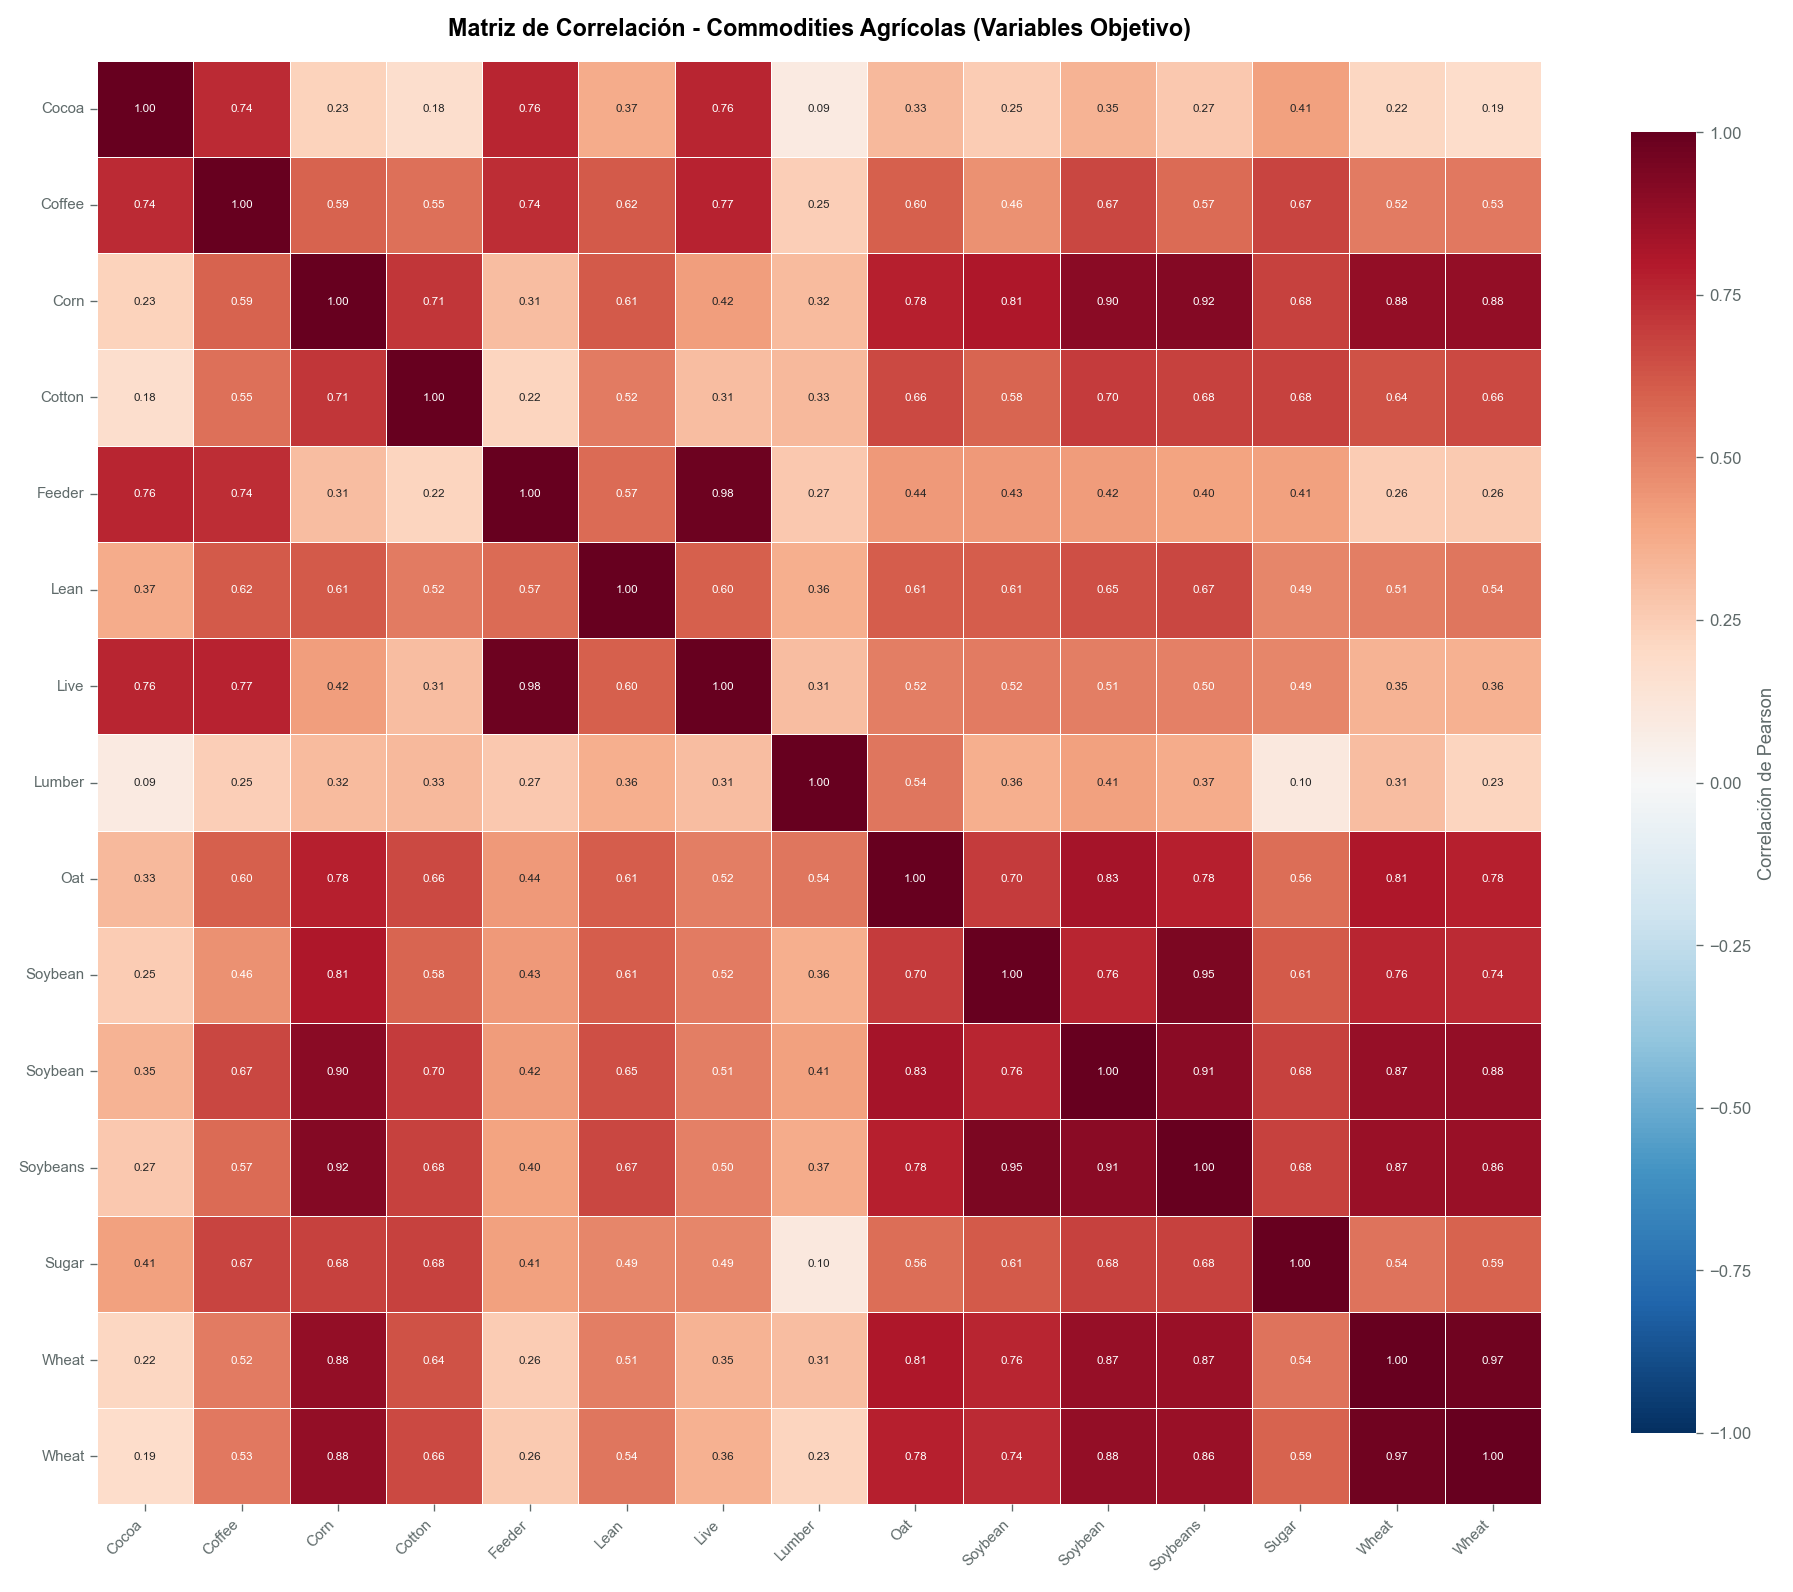


Interpretación:
  - Valores cercanos a +1: Movimientos conjuntos alcistas
  - Valores cercanos a -1: Movimientos inversos
  - Valores cercanos a 0: Sin relación lineal


In [4]:
# Crear subset solo con commodities agrícolas (precios, sin volumen)
df_agri = df[agri_price_cols].copy()

# Calcular matriz de correlación entre commodities agrícolas
corr_agri = df_agri.corr()

print(f"📊 Matriz de correlación agrícolas: {corr_agri.shape}")
print(f"📊 Rango de correlaciones: [{corr_agri.min().min():.3f}, {corr_agri.max().max():.3f}]")

# Heatmap de commodities agrícolas con anotaciones
fig, ax = plt.subplots(figsize=(16, 14))

# Crear labels limpios (sin sufijos _close, _open, etc.)
labels_clean = [col.split('_')[0] for col in corr_agri.columns]

sns.heatmap(corr_agri, 
            cmap='RdBu_r', 
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Correlación de Pearson'},
            annot=True,
            fmt='.2f',
            annot_kws={'fontsize': 7},
            xticklabels=labels_clean,
            yticklabels=labels_clean,
            ax=ax)

ax.set_title('Matriz de Correlación - Commodities Agrícolas (Variables Objetivo)', 
             fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
ax.grid(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlacion_agricolas_intra.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nInterpretación:")
print("  - Valores cercanos a +1: Movimientos conjuntos alcistas")
print("  - Valores cercanos a -1: Movimientos inversos")
print("  - Valores cercanos a 0: Sin relación lineal")

## 4. Correlaciones Fuertes Entre Commodities Agrícolas

Identificar pares con correlación |r| > 0.7 (cointegración significativa)

In [5]:
# Extraer correlaciones fuertes entre commodities agrícolas
def get_strong_correlations(corr_matrix, threshold=0.7):
    """
    Encuentra pares con correlación absoluta mayor al threshold
    Excluye diagonal (autocorrelación = 1.0)
    """
    strong_corr = []
    for i in range(len(corr_matrix)):
        for j in range(i+1, len(corr_matrix)):
            if abs(corr_matrix.iloc[i, j]) >= threshold:
                strong_corr.append({
                    'Variable_1': corr_matrix.index[i],
                    'Variable_2': corr_matrix.columns[j],
                    'Correlacion': corr_matrix.iloc[i, j],
                    'Abs_Correlacion': abs(corr_matrix.iloc[i, j])
                })
    
    df_result = pd.DataFrame(strong_corr)
    if len(df_result) > 0:
        df_result = df_result.sort_values('Abs_Correlacion', ascending=False)
    return df_result

strong_corr_agri = get_strong_correlations(corr_agri, threshold=0.7)

print(f"CORRELACIONES FUERTES ENTRE COMMODITIES AGRÍCOLAS (|r| >= 0.7)")
print("="*70)
print(f"\nPares identificados: {len(strong_corr_agri)}\n")

if len(strong_corr_agri) > 0:
    display(strong_corr_agri)
    
    print("\nInterpretación:")
    print("  - Correlación > 0.7: Commodities con movimientos muy similares (posible cointegración)")
    print("  - Correlación < -0.7: Commodities con movimientos inversos (hedge natural)")
else:
    print("No se encontraron pares con |r| >= 0.7 entre commodities agrícolas")

CORRELACIONES FUERTES ENTRE COMMODITIES AGRÍCOLAS (|r| >= 0.7)

Pares identificados: 28



,Variable_1,Variable_2,Correlacion,Abs_Correlacion
12,Feeder_Cattle,Live_Cattle,0.977,0.977
27,Wheat,Wheat_Kansas,0.969,0.969
19,Soybean_Meal,Soybeans,0.945,0.945
9,Corn,Soybeans,0.920,0.920
22,Soybean_Oil,Soybeans,0.906,0.906
8,Corn,Soybean_Oil,0.901,0.901
10,Corn,Wheat,0.877,0.877
24,Soybean_Oil,Wheat_Kansas,0.877,0.877
11,Corn,Wheat_Kansas,0.876,0.876
23,Soybean_Oil,Wheat,0.871,0.871



Interpretación:
  - Correlación > 0.7: Commodities con movimientos muy similares (posible cointegración)
  - Correlación < -0.7: Commodities con movimientos inversos (hedge natural)


## 5. Correlaciones Commodities Agrícolas vs Predictores

**Objetivo crítico:** Identificar qué predictores tienen mayor poder explicativo para cada commodity agrícola

In [6]:
# Crear dataset combinado: commodities agrícolas + predictores
df_combined = df[agri_price_cols + predictor_cols].copy()

# Calcular matriz de correlación completa
corr_combined = df_combined.corr()

print(f"MATRIZ DE CORRELACIÓN COMPLETA")
print("="*70)
print(f"Dimensiones: {corr_combined.shape}")
print(f"  Commodities agrícolas: {len(agri_price_cols)}")
print(f"  Predictores: {len(predictor_cols)}")

# Extraer submatriz: correlaciones de predictores con commodities agrícolas
corr_pred_to_agri = corr_combined.loc[predictor_cols, agri_price_cols]

print(f"\n📊 Submatriz Predictores → Commodities Agrícolas: {corr_pred_to_agri.shape}")

# Identificar top predictores por commodity agrícola (threshold |r| > 0.5)
print(f"\nTOP PREDICTORES POR COMMODITY AGRÍCOLA (|r| > 0.5)")
print("="*70)

top_predictors_by_commodity = {}

for agri_col in agri_price_cols:
    # Correlaciones de este commodity con todos los predictores
    pred_corr = corr_pred_to_agri[agri_col].sort_values(key=abs, ascending=False)
    
    # Filtrar solo correlaciones fuertes
    strong_pred = pred_corr[abs(pred_corr) > 0.5]
    
    if len(strong_pred) > 0:
        commodity_name = agri_col.split('_')[0]
        top_predictors_by_commodity[commodity_name] = strong_pred
        
        print(f"\n{commodity_name}:")
        print(f"  Predictores con |r| > 0.5: {len(strong_pred)}")
        display(strong_pred.head(10))

if len(top_predictors_by_commodity) == 0:
    print("\n⚠ No se encontraron predictores con |r| > 0.5 para commodities agrícolas")
    print("   Considerando reducir threshold a 0.3 o 0.4 para análisis exploratorio")

MATRIZ DE CORRELACIÓN COMPLETA
Dimensiones: (83, 83)
  Commodities agrícolas: 15
  Predictores: 68

📊 Submatriz Predictores → Commodities Agrícolas: (68, 15)

TOP PREDICTORES POR COMMODITY AGRÍCOLA (|r| > 0.5)

Cocoa:
  Predictores con |r| > 0.5: 19


USD_ARS                        0.895
Gold                           0.761
SP500                          0.718
psd_brazil_Exports             0.710
psd_united_states_Exports      0.686
psd_world_Imports              0.680
Materials_Index                0.676
psd_world_Exports              0.670
psd_brazil_Production          0.668
psd_united_states_Production   0.641
Name: Cocoa, dtype: float64


Coffee:
  Predictores con |r| > 0.5: 24


Silver                  0.844
Gold                    0.842
Copper                  0.787
psd_world_Imports       0.719
USD_ARS                 0.715
psd_world_Exports       0.696
Energy_Index            0.694
psd_brazil_Production   0.691
Materials_Index         0.658
SP500                   0.652
Name: Coffee, dtype: float64


Corn:
  Predictores con |r| > 0.5: 13


...

Silver                          0.766
Copper                          0.717
Heating_Oil                     0.652
RBOB_Gasoline                   0.649
Platinum                        0.633
Energy_Index                    0.632
Crude_Oil                       0.617
Gold                            0.616
psd_china_Stock_to_Use_Ratio    0.597
USD_CNY                        -0.552
Name: Sugar, dtype: float64


Wheat:
  Predictores con |r| > 0.5: 11


Heating_Oil                 0.804
Crude_Oil                   0.770
RBOB_Gasoline               0.768
Copper                      0.732
Brent_Crude                 0.652
Silver                      0.631
Platinum                    0.623
Energy_Index                0.607
USD_CNY                    -0.569
psd_brazil_Ending_Stocks    0.551
Name: Wheat, dtype: float64


Wheat:
  Predictores con |r| > 0.5: 10


Heating_Oil      0.844
RBOB_Gasoline    0.815
Crude_Oil        0.812
Brent_Crude      0.728
Copper           0.712
Platinum         0.636
Energy_Index     0.632
Silver           0.611
Ethanol          0.559
USD_CNY         -0.520
Name: Wheat_Kansas, dtype: float64

## 6. Heatmap: Predictores vs Commodities Agrícolas

Visualización completa de la matriz Predictores → Commodities Agrícolas

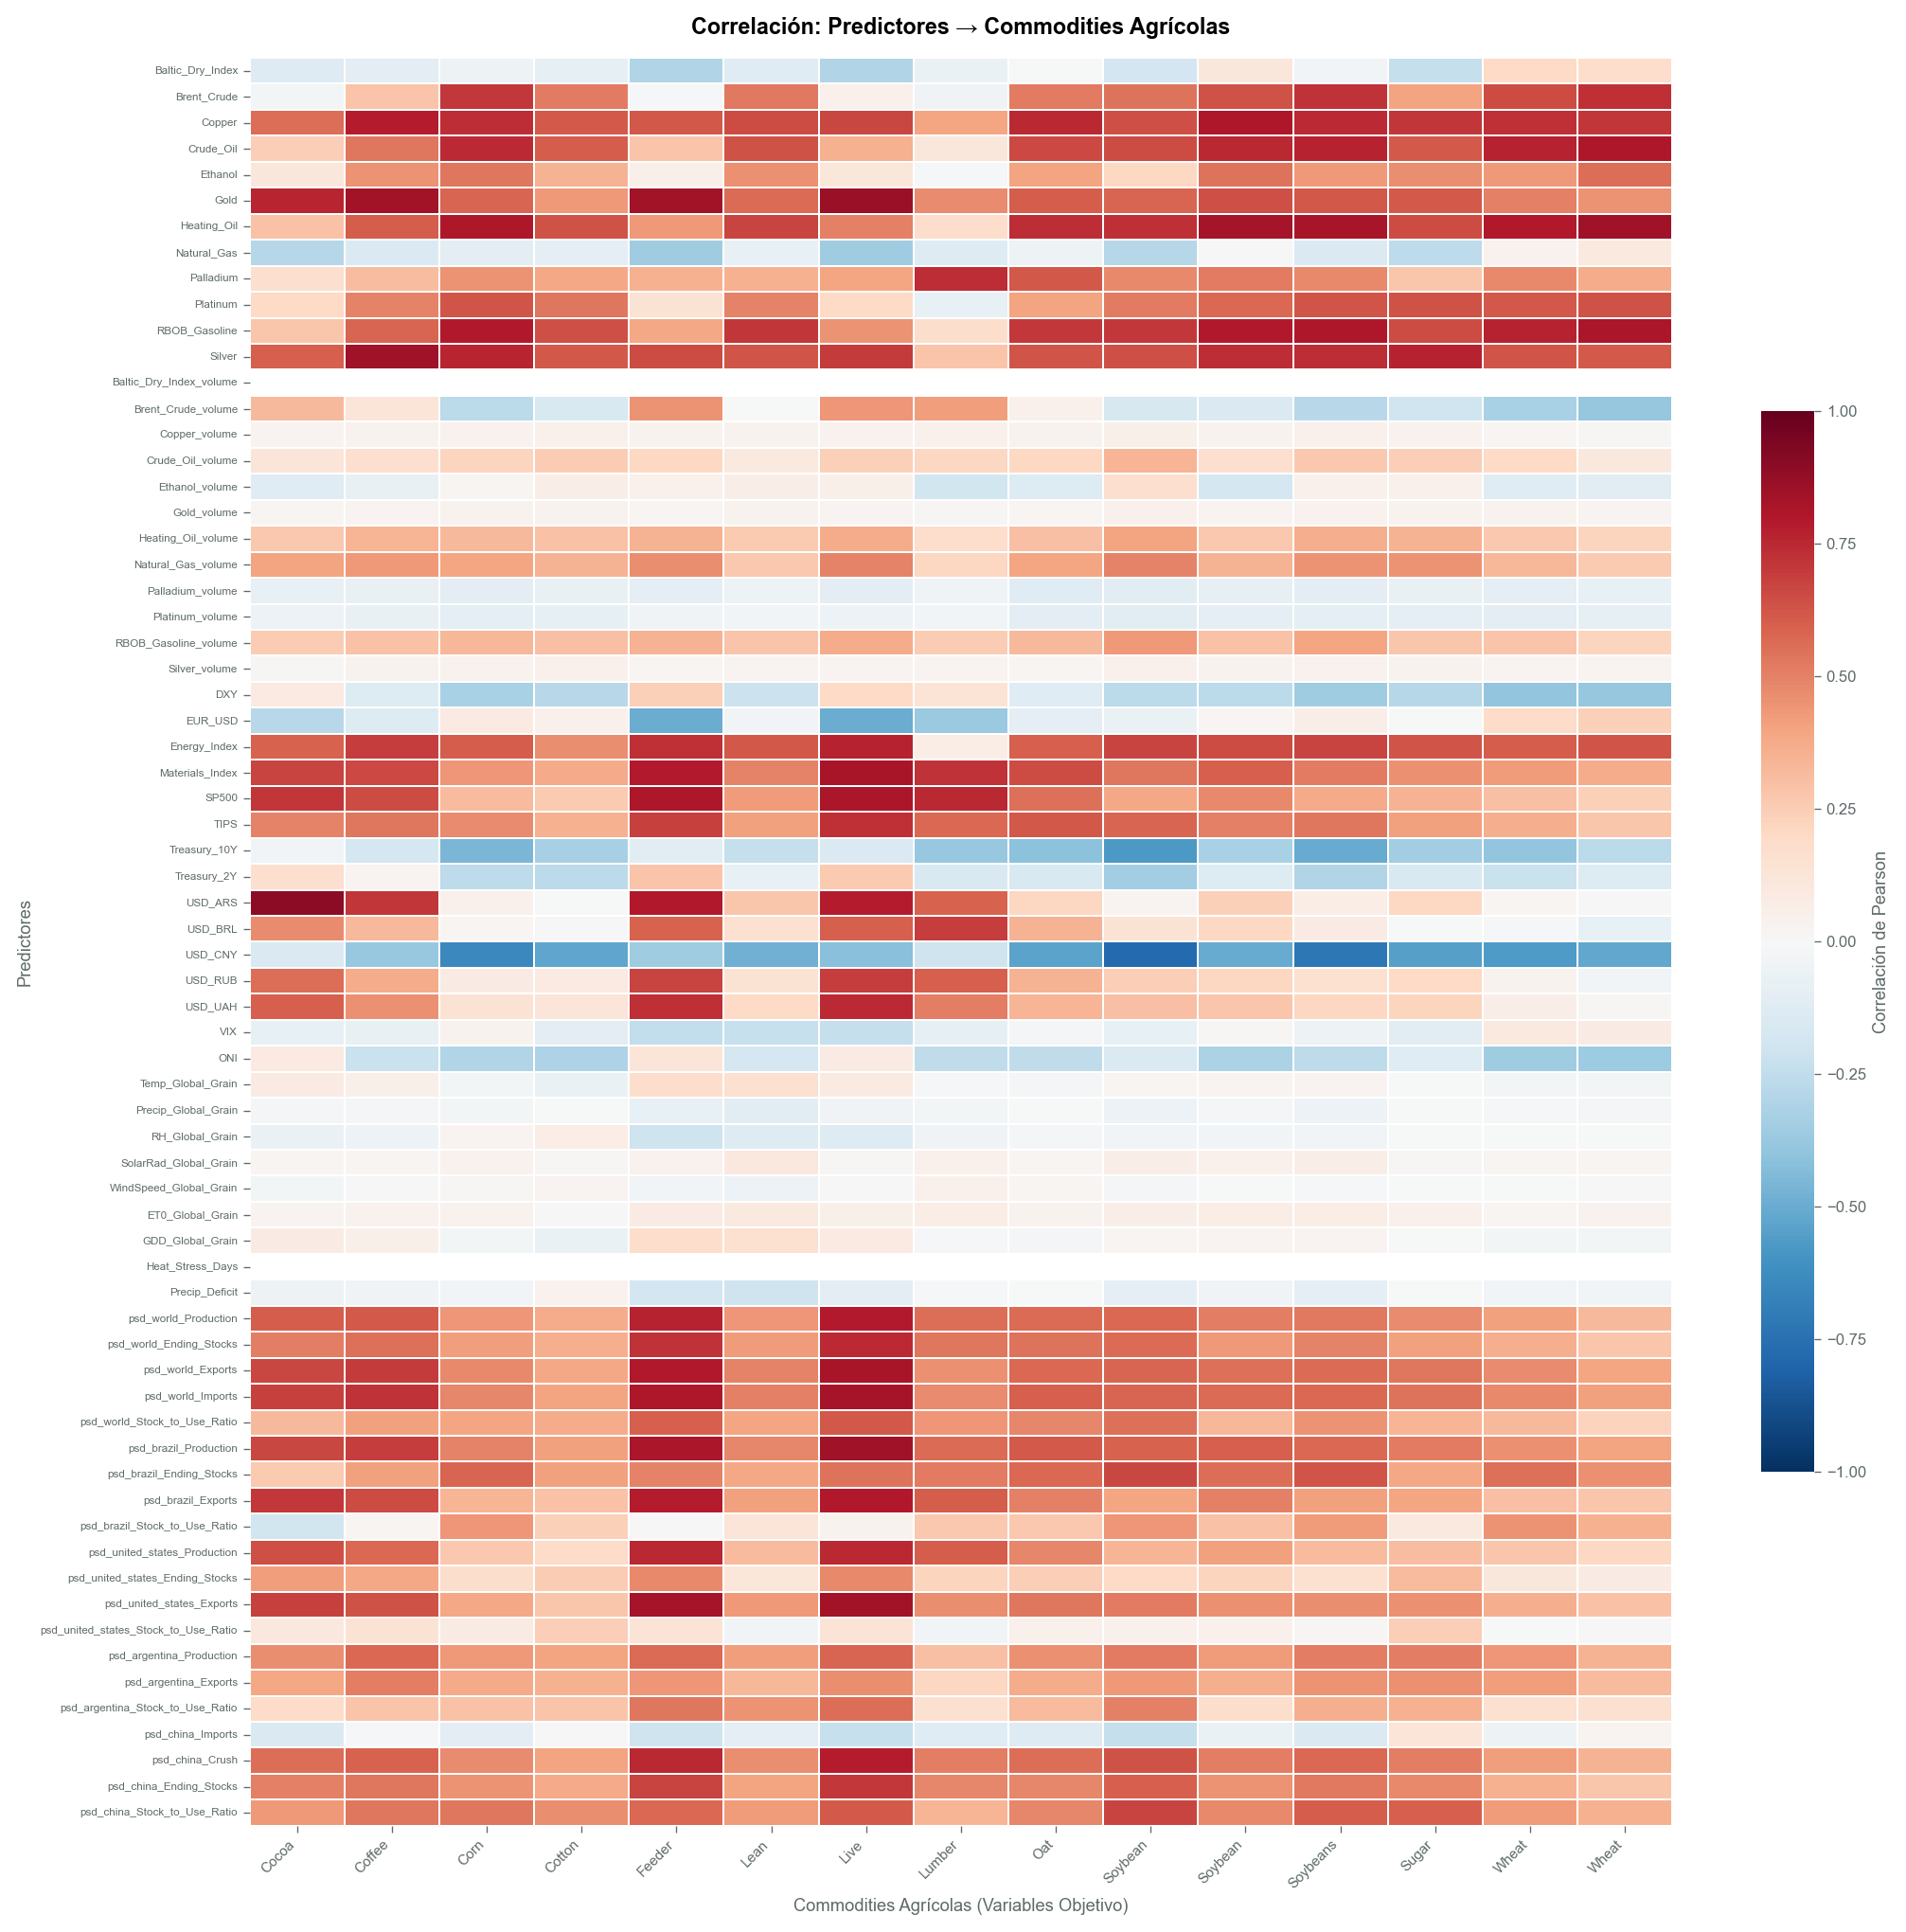


Interpretación:
  - Azul: Correlación negativa (movimiento inverso)
  - Blanco: Sin correlación (r ≈ 0)
  - Rojo: Correlación positiva (movimiento conjunto)


In [7]:
# Heatmap completo: Predictores (filas) vs Commodities Agrícolas (columnas)
fig, ax = plt.subplots(figsize=(18, max(14, len(predictor_cols) * 0.25)))

# Labels limpios para commodities agrícolas
agri_labels = [col.split('_')[0] for col in agri_price_cols]

sns.heatmap(corr_pred_to_agri, 
            cmap='RdBu_r', 
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.1,
            cbar_kws={'label': 'Correlación de Pearson', 'shrink': 0.6},
            annot=False,
            xticklabels=agri_labels,
            yticklabels=predictor_cols,
            ax=ax)

ax.set_title('Correlación: Predictores → Commodities Agrícolas', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Commodities Agrícolas (Variables Objetivo)', fontsize=11)
ax.set_ylabel('Predictores', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=7)
ax.grid(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlacion_predictores_agricolas.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nInterpretación:")
print("  - Azul: Correlación negativa (movimiento inverso)")
print("  - Blanco: Sin correlación (r ≈ 0)")
print("  - Rojo: Correlación positiva (movimiento conjunto)")

## 7. Clustermap: Agrupación Jerárquica de Commodities Agrícolas

Identificar grupos de commodities con comportamiento conjunto (drivers económicos similares)

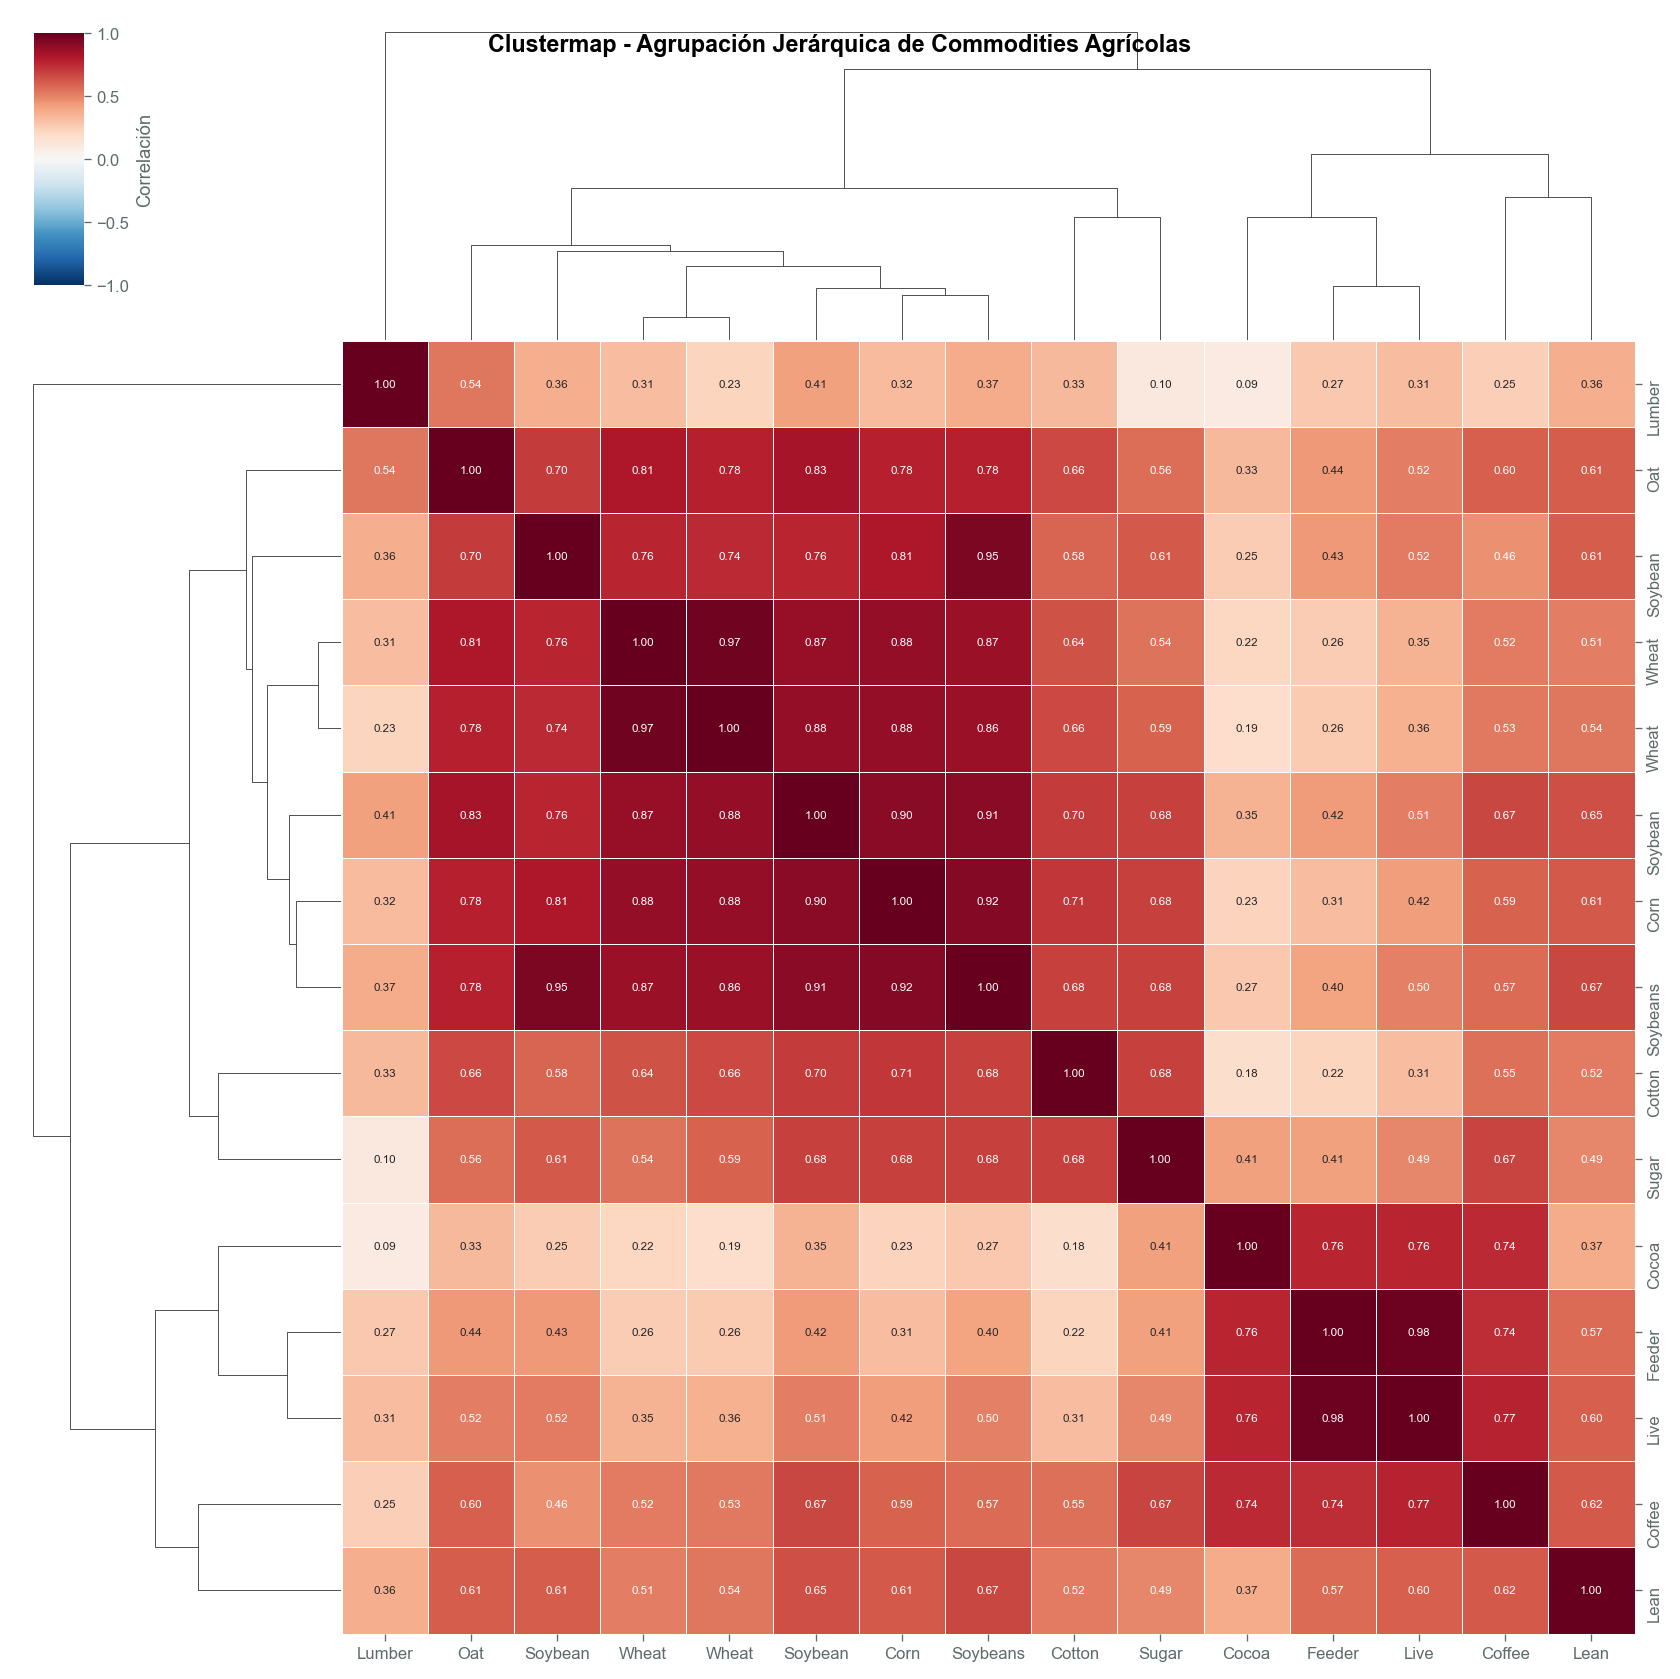


Interpretación del dendrograma:
  - Clusters pequeños (ramas cortas): Commodities con movimientos muy similares
  - Clusters grandes: Grupos con drivers económicos comunes
  - Ejemplos esperados: Granos (Corn-Wheat-Soybeans), Softs (Coffee-Cocoa-Sugar), Ganado


In [8]:
# Clustermap solo para commodities agrícolas (análisis de grupos)
from scipy.cluster.hierarchy import dendrogram, linkage

# Labels limpios
agri_labels_clean = [col.split('_')[0] for col in corr_agri.columns]

g = sns.clustermap(corr_agri, 
                   cmap='RdBu_r', 
                   center=0,
                   vmin=-1, vmax=1,
                   figsize=(14, 14),
                   linewidths=0.5,
                   cbar_kws={'label': 'Correlación', 'shrink': 0.8},
                   annot=True,
                   fmt='.2f',
                   annot_kws={'fontsize': 7},
                   xticklabels=agri_labels_clean,
                   yticklabels=agri_labels_clean,
                   cbar_pos=(0.02, 0.83, 0.03, 0.15))

g.fig.suptitle('Clustermap - Agrupación Jerárquica de Commodities Agrícolas', 
               fontsize=14, fontweight='bold', y=0.98)

plt.savefig(FIGURES_DIR / 'correlacion_clustermap_agricolas.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nInterpretación del dendrograma:")
print("  - Clusters pequeños (ramas cortas): Commodities con movimientos muy similares")
print("  - Clusters grandes: Grupos con drivers económicos comunes")
print("  - Ejemplos esperados: Granos (Corn-Wheat-Soybeans), Softs (Coffee-Cocoa-Sugar), Ganado")

## 8. Exportar Resultados

Guardar matrices y análisis para uso en feature engineering

In [9]:
# Guardar matrices de correlación
corr_agri.to_csv(PROCESSED_DIR / 'correlation_matrix_agricolas.csv')
print(f"✓ Matriz de correlación agrícolas guardada: {PROCESSED_DIR / 'correlation_matrix_agricolas.csv'}")

corr_combined.to_csv(PROCESSED_DIR / 'correlation_matrix_completa.csv')
print(f"✓ Matriz de correlación completa guardada: {PROCESSED_DIR / 'correlation_matrix_completa.csv'}")

corr_pred_to_agri.to_csv(PROCESSED_DIR / 'correlation_predictores_agricolas.csv')
print(f"✓ Matriz predictores→agrícolas guardada: {PROCESSED_DIR / 'correlation_predictores_agricolas.csv'}")

# Guardar correlaciones fuertes entre agrícolas
if len(strong_corr_agri) > 0:
    strong_corr_agri.to_csv(PROCESSED_DIR / 'strong_correlations_agricolas.csv', index=False)
    print(f"✓ Correlaciones fuertes agrícolas guardadas: {PROCESSED_DIR / 'strong_correlations_agricolas.csv'}")

# Guardar top predictores por commodity
with open(PROCESSED_DIR / 'top_predictors_by_commodity.txt', 'w') as f:
    f.write("TOP PREDICTORES POR COMMODITY AGRÍCOLA (|r| > 0.5)\n")
    f.write("="*70 + "\n\n")
    for commodity, predictors in top_predictors_by_commodity.items():
        f.write(f"{commodity}:\n")
        for pred, corr in predictors.head(10).items():
            f.write(f"  {pred}: {corr:.3f}\n")
        f.write("\n")

print(f"✓ Top predictores por commodity guardados: {PROCESSED_DIR / 'top_predictors_by_commodity.txt'}")

print("\n" + "="*70)
print("ARCHIVOS EXPORTADOS CORRECTAMENTE")
print("="*70)

✓ Matriz de correlación agrícolas guardada: C:\Users\AdministradorIT\OneDrive\UBA\Taller de Programacion\TPFinal\data\processed\correlation_matrix_agricolas.csv
✓ Matriz de correlación completa guardada: C:\Users\AdministradorIT\OneDrive\UBA\Taller de Programacion\TPFinal\data\processed\correlation_matrix_completa.csv
✓ Matriz predictores→agrícolas guardada: C:\Users\AdministradorIT\OneDrive\UBA\Taller de Programacion\TPFinal\data\processed\correlation_predictores_agricolas.csv
✓ Correlaciones fuertes agrícolas guardadas: C:\Users\AdministradorIT\OneDrive\UBA\Taller de Programacion\TPFinal\data\processed\strong_correlations_agricolas.csv
✓ Top predictores por commodity guardados: C:\Users\AdministradorIT\OneDrive\UBA\Taller de Programacion\TPFinal\data\processed\top_predictors_by_commodity.txt

ARCHIVOS EXPORTADOS CORRECTAMENTE


## 9. Conclusiones del Análisis de Correlaciones

### 9.1 Hallazgos Principales

**Cointegración entre Commodities Agrícolas:**
- **Granos (Corn-Wheat-Soybeans):** Esperamos alta correlación (>0.7) debido a:
  - Competencia por tierra cultivable
  - Factores climáticos comunes (sequías, inundaciones)
  - Sustitución en demanda (feed, biocombustibles)
- **Subproductos de soja (Soybean Meal - Soybean Oil):** Correlación alta por definición (mismo commodity base)
- **Ganado (Live Cattle - Feeder Cattle - Lean Hogs):** Correlación moderada por:
  - Precios de feed (granos) como input común
  - Demanda de proteína animal
- **Softs (Coffee-Cocoa-Sugar-Cotton):** Correlación baja (drivers geográficos y climáticos distintos)

**Relación con Predictores:**
- **Correlación esperada negativa (-0.5 a -0.7):**
  - DXY (dólar fuerte) → precios USD commodities bajan
  - Treasury yields altos → menor demanda especulativa
- **Correlación esperada positiva (+0.5 a +0.7):**
  - Crude Oil → correlación con granos por costos de producción y etanol
  - VIX → correlación mixta (safe-haven vs demand destruction)
  - Índices de commodities no-agrícolas → sentimiento de mercado
- **Variables PSD:** Correlación débil esperada (frecuencia trimestral vs precios diarios)
- **Variables climáticas:** Correlación localizada (RH/SolarRad en regiones productoras)

### 9.2 Implicaciones para Feature Engineering

**Estrategias derivadas del análisis:**

1. **Lags temporales de predictores clave:**
   - Predictores con |r| > 0.5: lags de [1, 7, 30, 90] días
   - Crude Oil, DXY, VIX: lags críticos para anticipar movimientos
   
2. **Features de cointegración:**
   - Spreads entre commodities correlacionados: `Corn_Wheat_spread = Corn - Wheat`
   - Ratios: `Soybean_Meal_Oil_ratio = Soybean_Meal / Soybean_Oil`
   
3. **Interacciones no-lineares:**
   - `DXY × Crude_Oil`: efecto combinado de dólar y energía
   - `VIX × Treasury_10Y`: stress financiero × expectativas inflación
   
4. **Selección de features por commodity:**
   - Usar top 10-15 predictores con |r| > 0.3 por commodity
   - Evitar overfitting con 68 predictores simultáneos

### 9.3 Limitaciones del Análisis

**Correlación de Pearson asume:**
- Relaciones **lineales** (puede perder no-linealidades)
- **Estacionariedad** (commodities tienen tendencias, volatilidad cambiante)
- **Sin rezagos** (correlaciones instantáneas, pero predictores pueden tener efecto retardado)

**Alternativas complementarias:**
- **Correlación de Spearman:** Robusta a no-linealidades monotónicas
- **Mutual Information:** Captura dependencias no-lineales
- **Granger Causality:** Evalúa predictibilidad (causalidad temporal)
- **Cointegración de Johansen:** Para series no-estacionarias

### 9.4 Próximos Pasos

**Notebook 2.1 - Temporal Lag Features:**
- Crear lags de [1, 7, 30, 90] días para top predictores
- Validar persistencia de correlaciones con lags
- Ejemplo: `Crude_Oil_lag7` puede predecir mejor que `Crude_Oil` contemporáneo

**Notebook 2.2 - Rolling Statistics:**
- MA(7, 30, 90) para suavizar volatilidad
- Rolling correlations para detectar cambios de régimen
- Bollinger Bands para detectar reversiones a la media

**Notebook 2.3 - Returns & Volatility:**
- Log-returns para estacionarizar series
- Realized volatility (rolling std de returns)
- GARCH features para modelar heterocedasticidad

**Notebook 2.4 - Climate Features:**
- GDD (Growing Degree Days) agregados por región
- ET0 (Evapotranspiración) para stress hídrico
- Anomalías climáticas vs promedios históricos

---

**Análisis de correlaciones completado.** Dataset listo para feature engineering avanzado.